In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_banknote_authentication.txt to data_banknote_authentication (2).txt


In [ ]:
bank_data = pd.read_csv("data_banknote_authentication.txt",header=None,names=["variance", "skewness", "curtosis", "entropy", "class"])

In [ ]:
bank_data.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
print("Shape:", bank_data.shape)

Shape: (1372, 5)


In [ ]:
print(bank_data.columns)

Index(['variance', 'skewness', 'curtosis', 'entropy', 'class'], dtype='object')


In [ ]:
print(bank_data.isnull().sum())

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64


In [ ]:
bank_data.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


<Figure size 4800x3600 with 0 Axes>

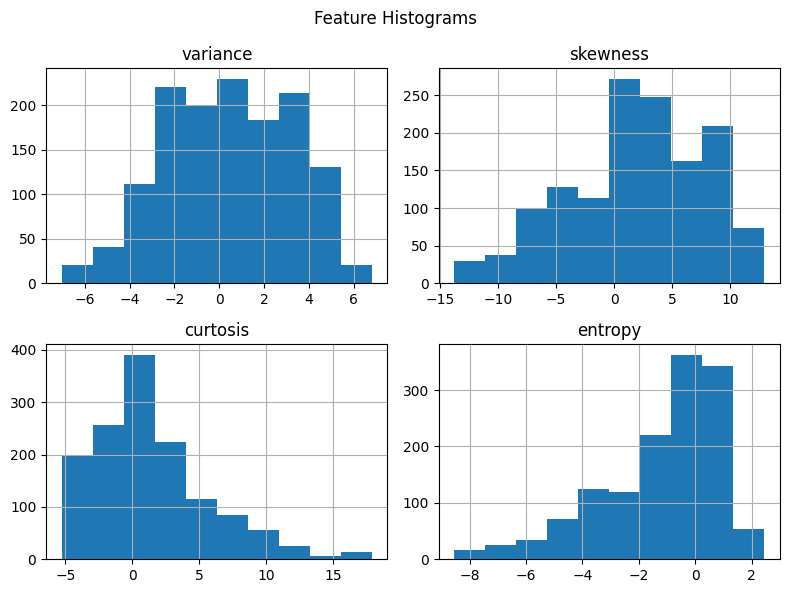

In [ ]:
plt.figure(figsize=(8,6), dpi=600)
bank_data.iloc[:, :-1].hist(figsize=(8,6))
plt.suptitle("Feature Histograms")
plt.tight_layout()
plt.savefig("Histogram.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

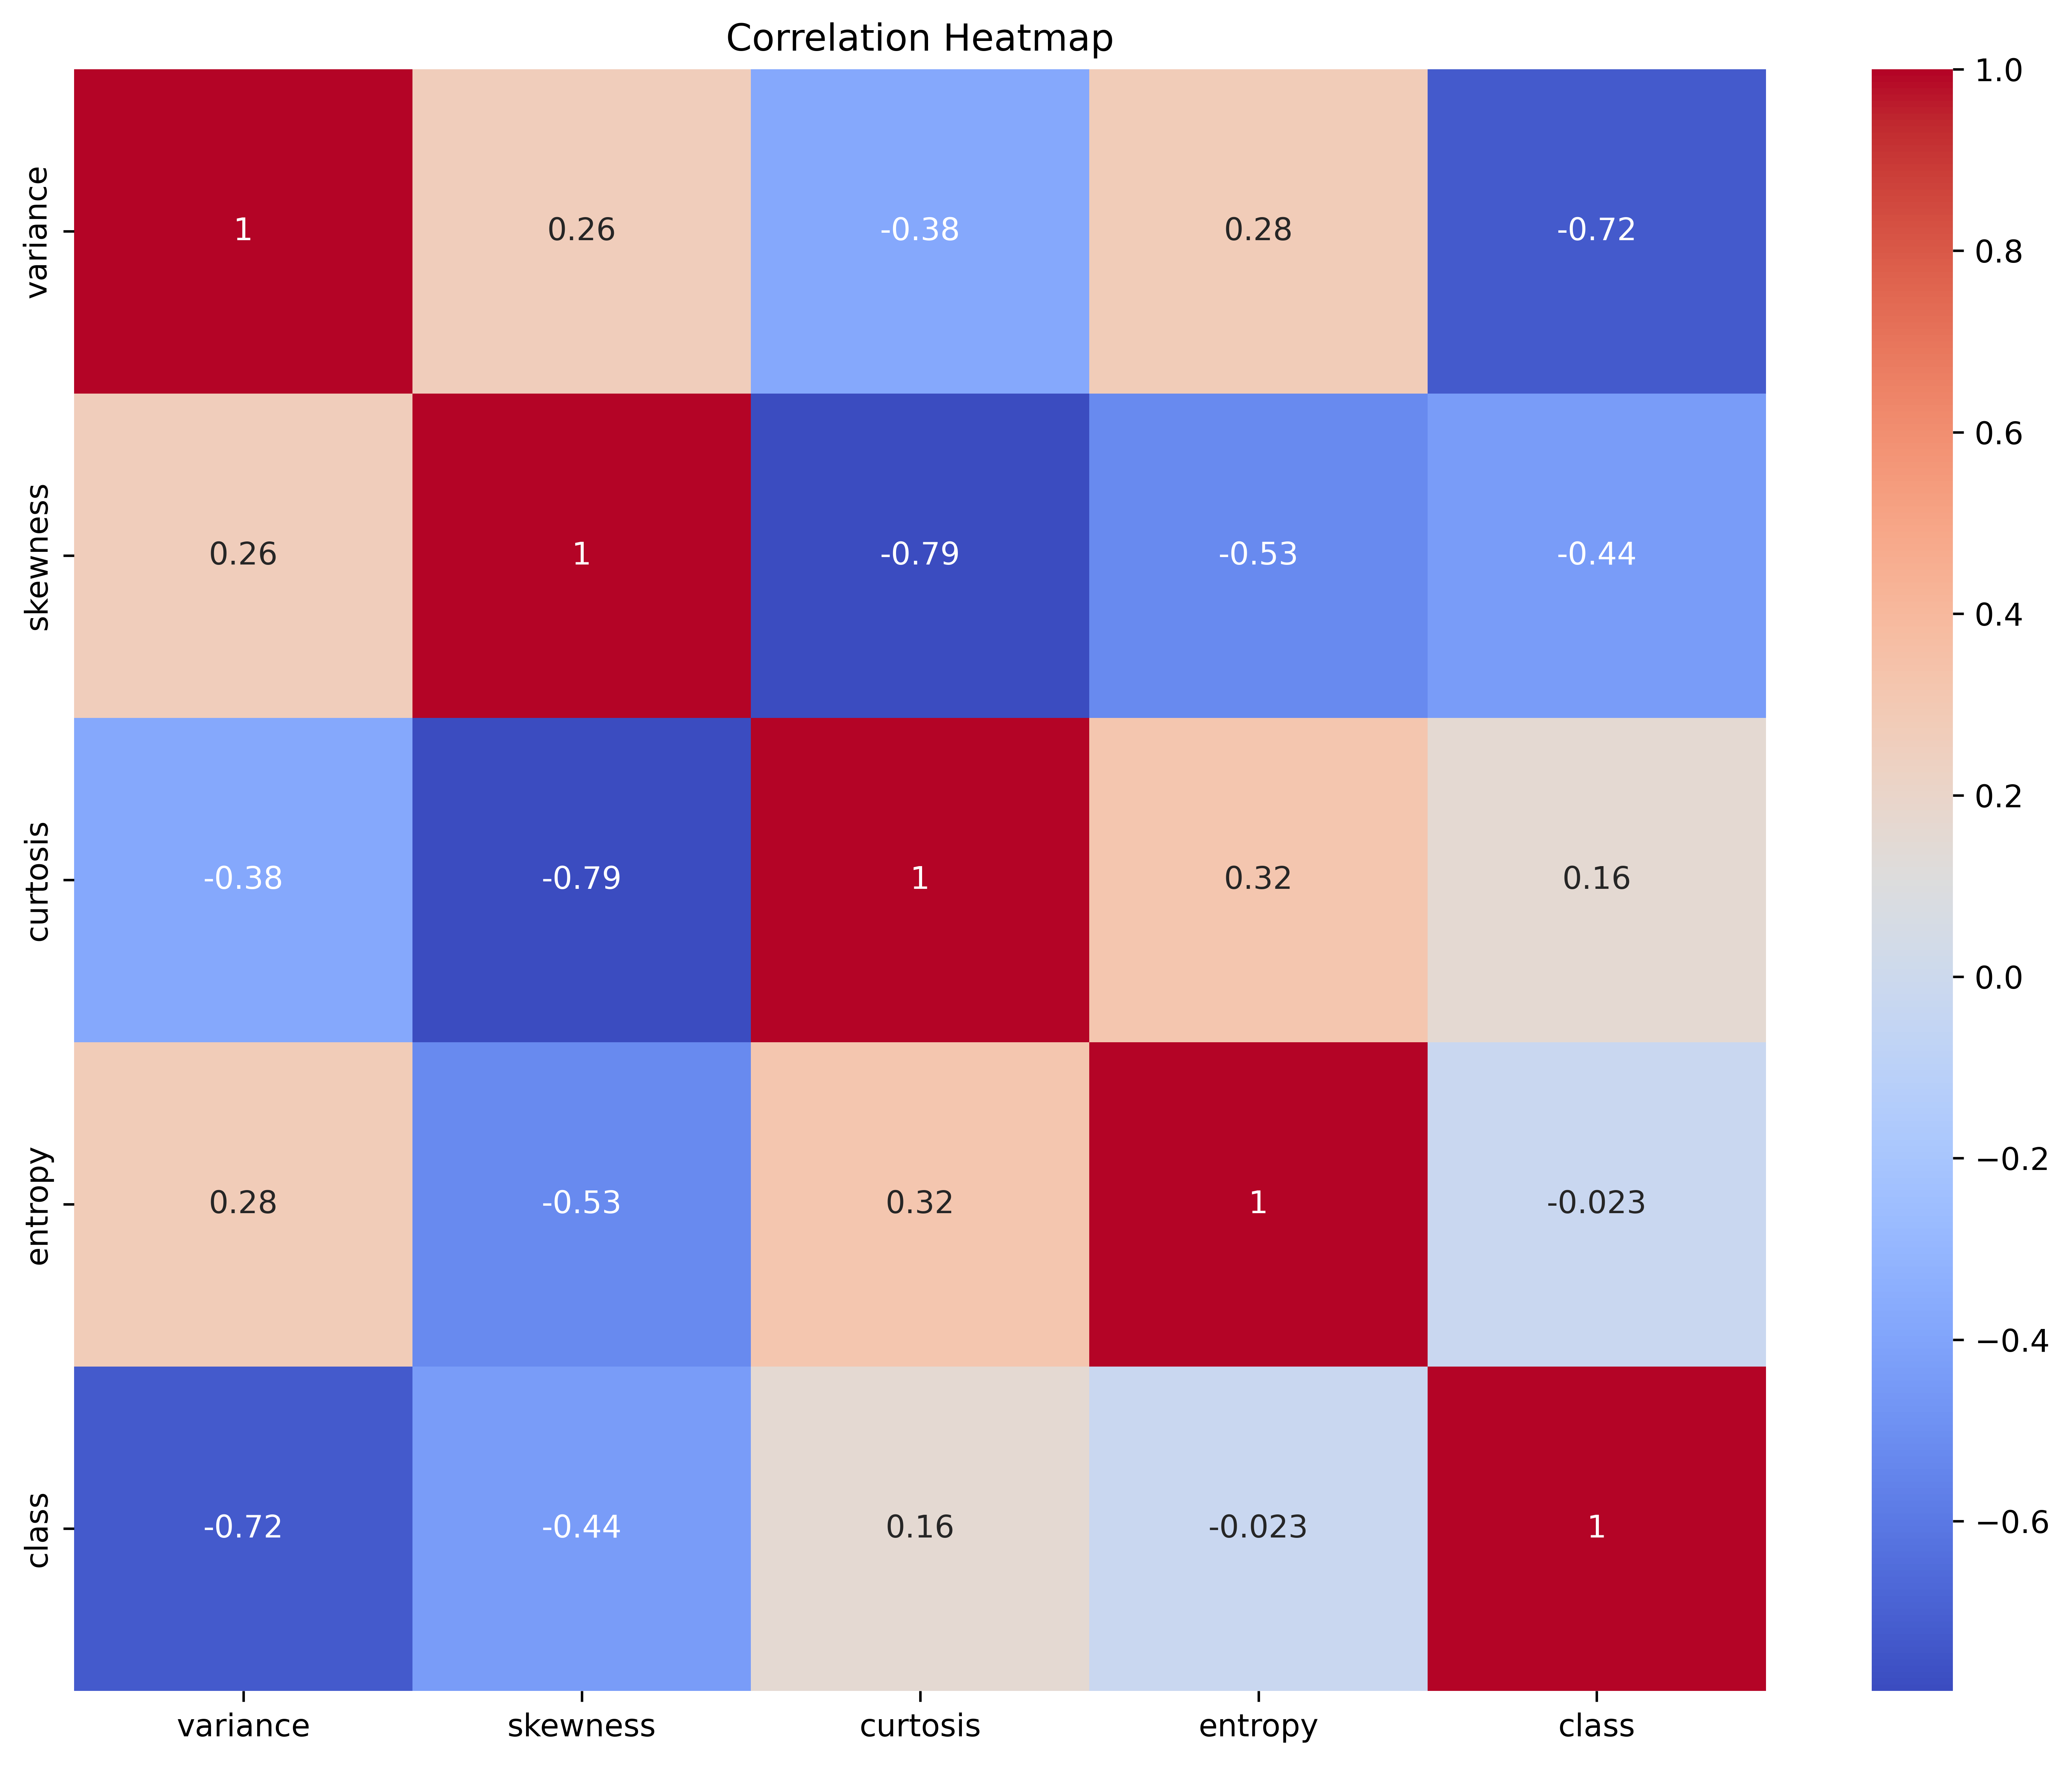

In [ ]:
plt.figure(figsize=(10,8),dpi=600)
sns.heatmap(bank_data.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("Correlation_Heatmap.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

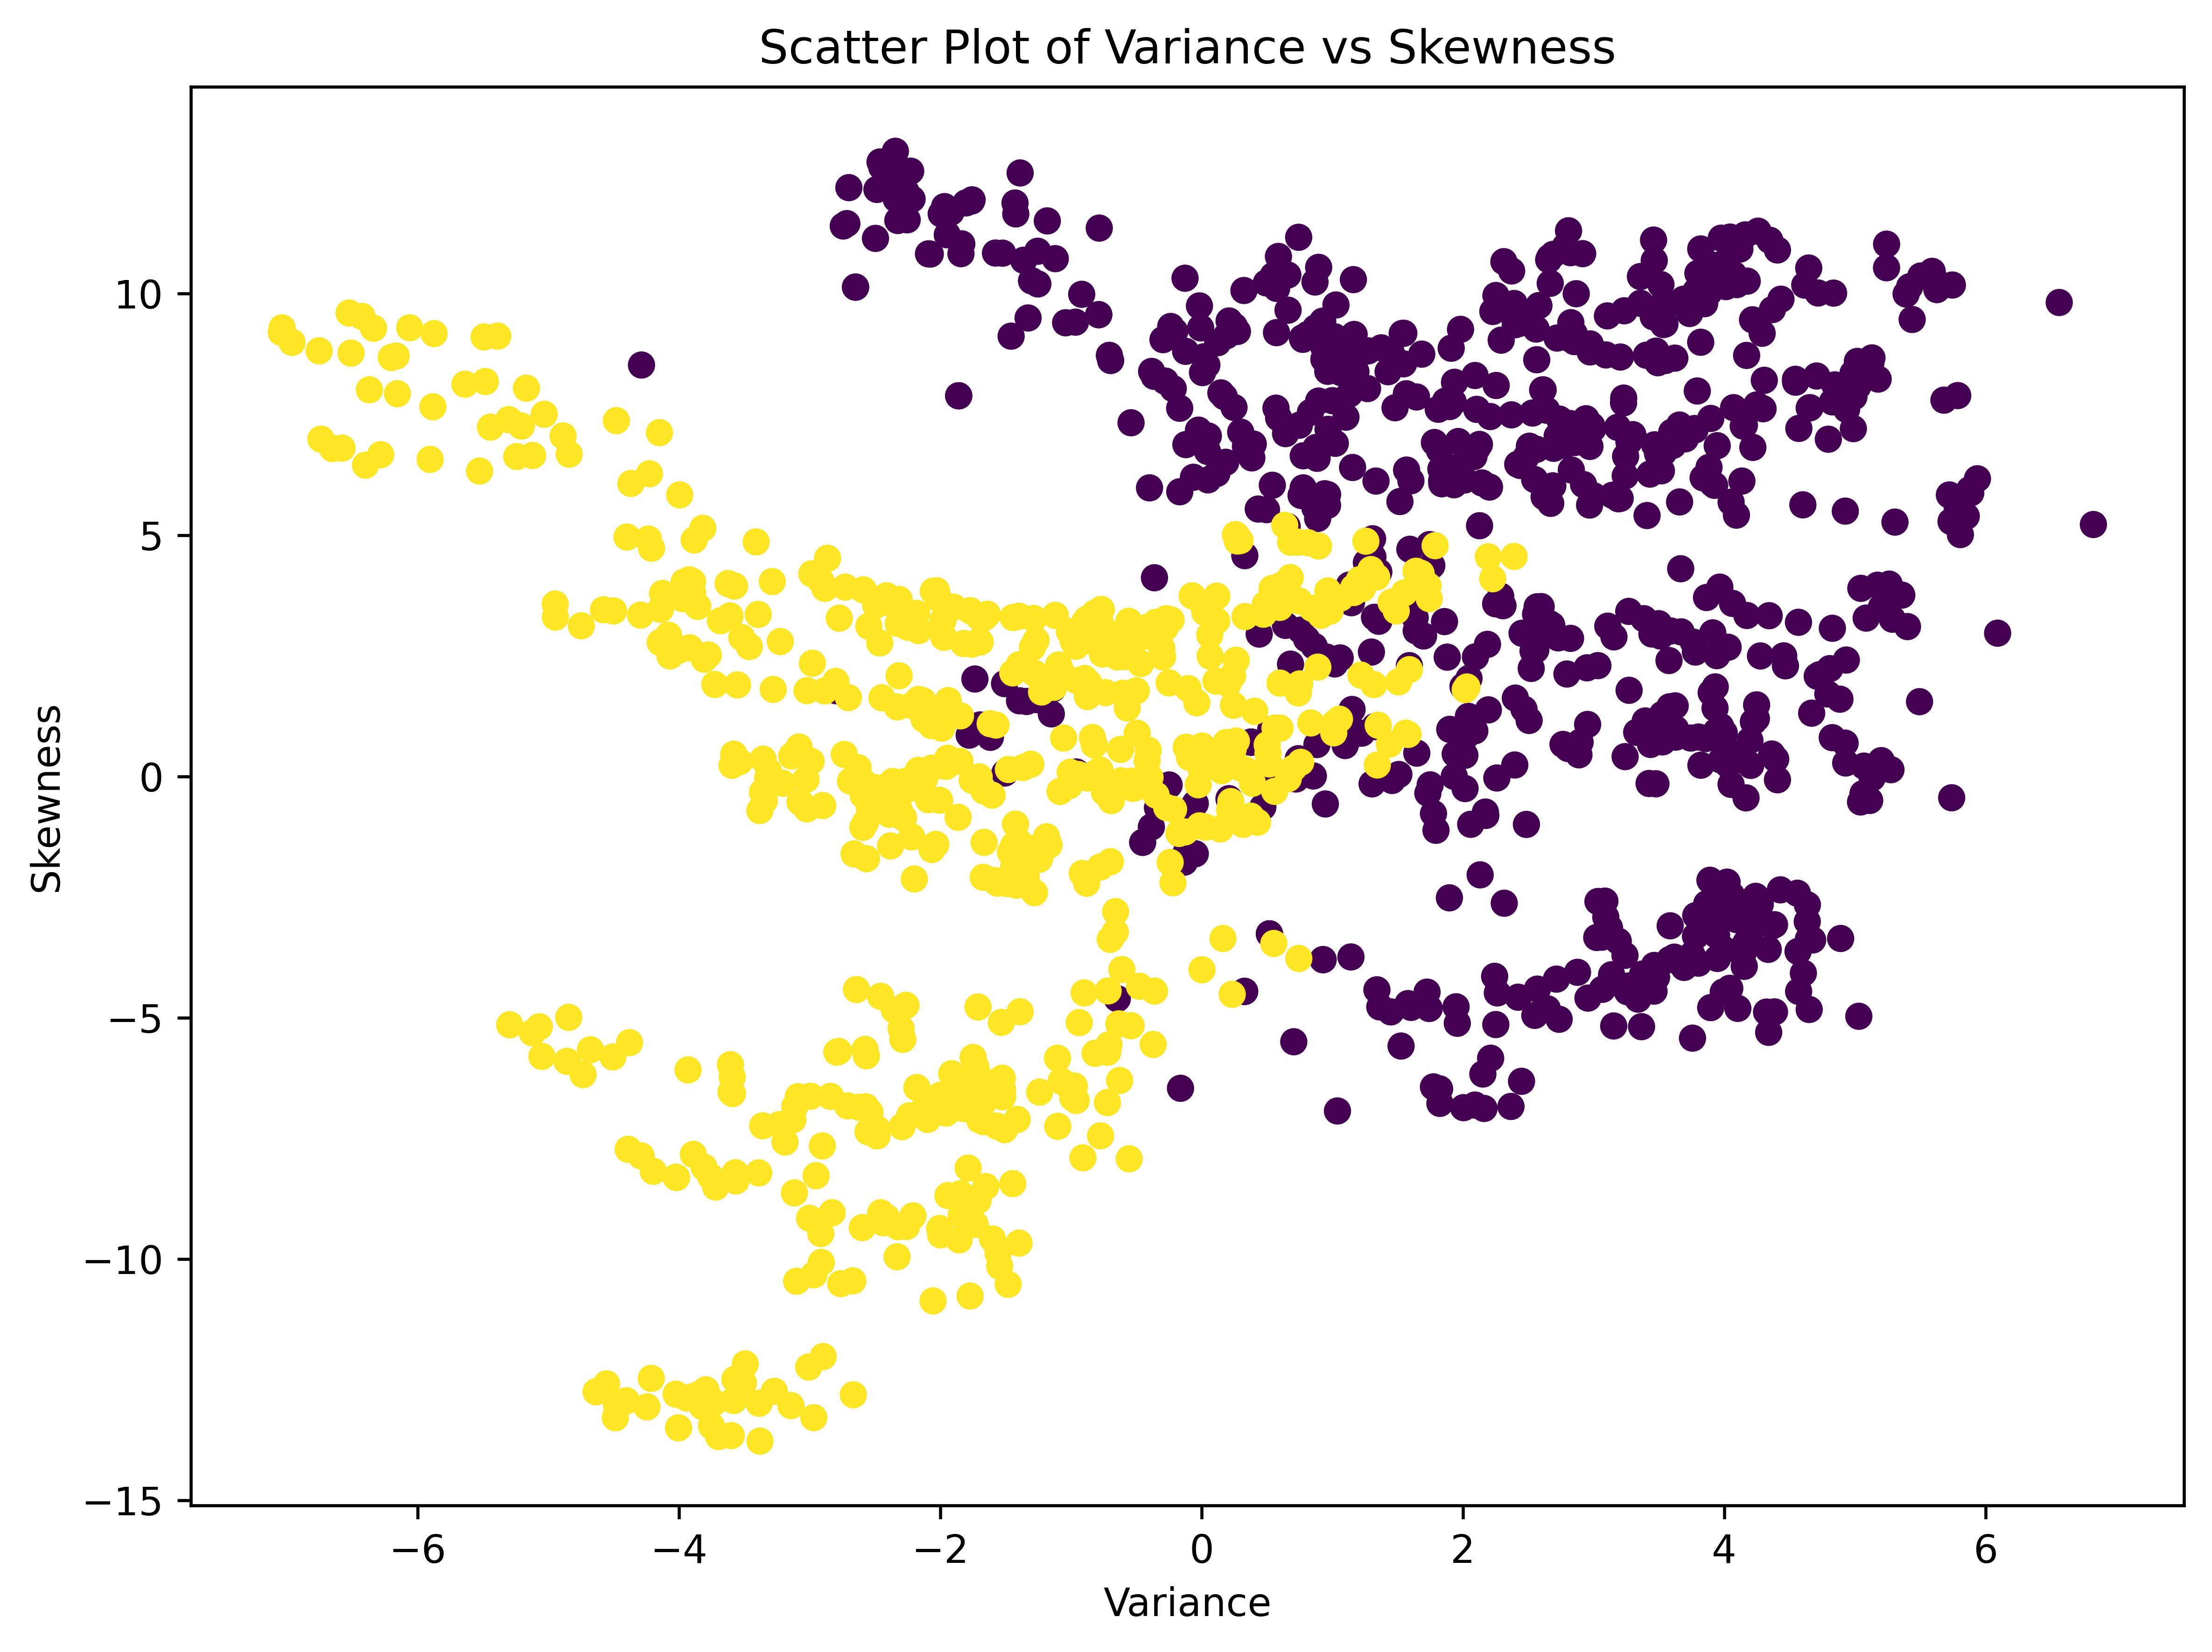

In [ ]:
plt.figure(figsize=(8,6), dpi=600)
plt.scatter(bank_data["variance"],bank_data["skewness"],c=bank_data["class"])
plt.title("Scatter Plot of Variance vs Skewness")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.tight_layout()
plt.savefig("ScatterPlot.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

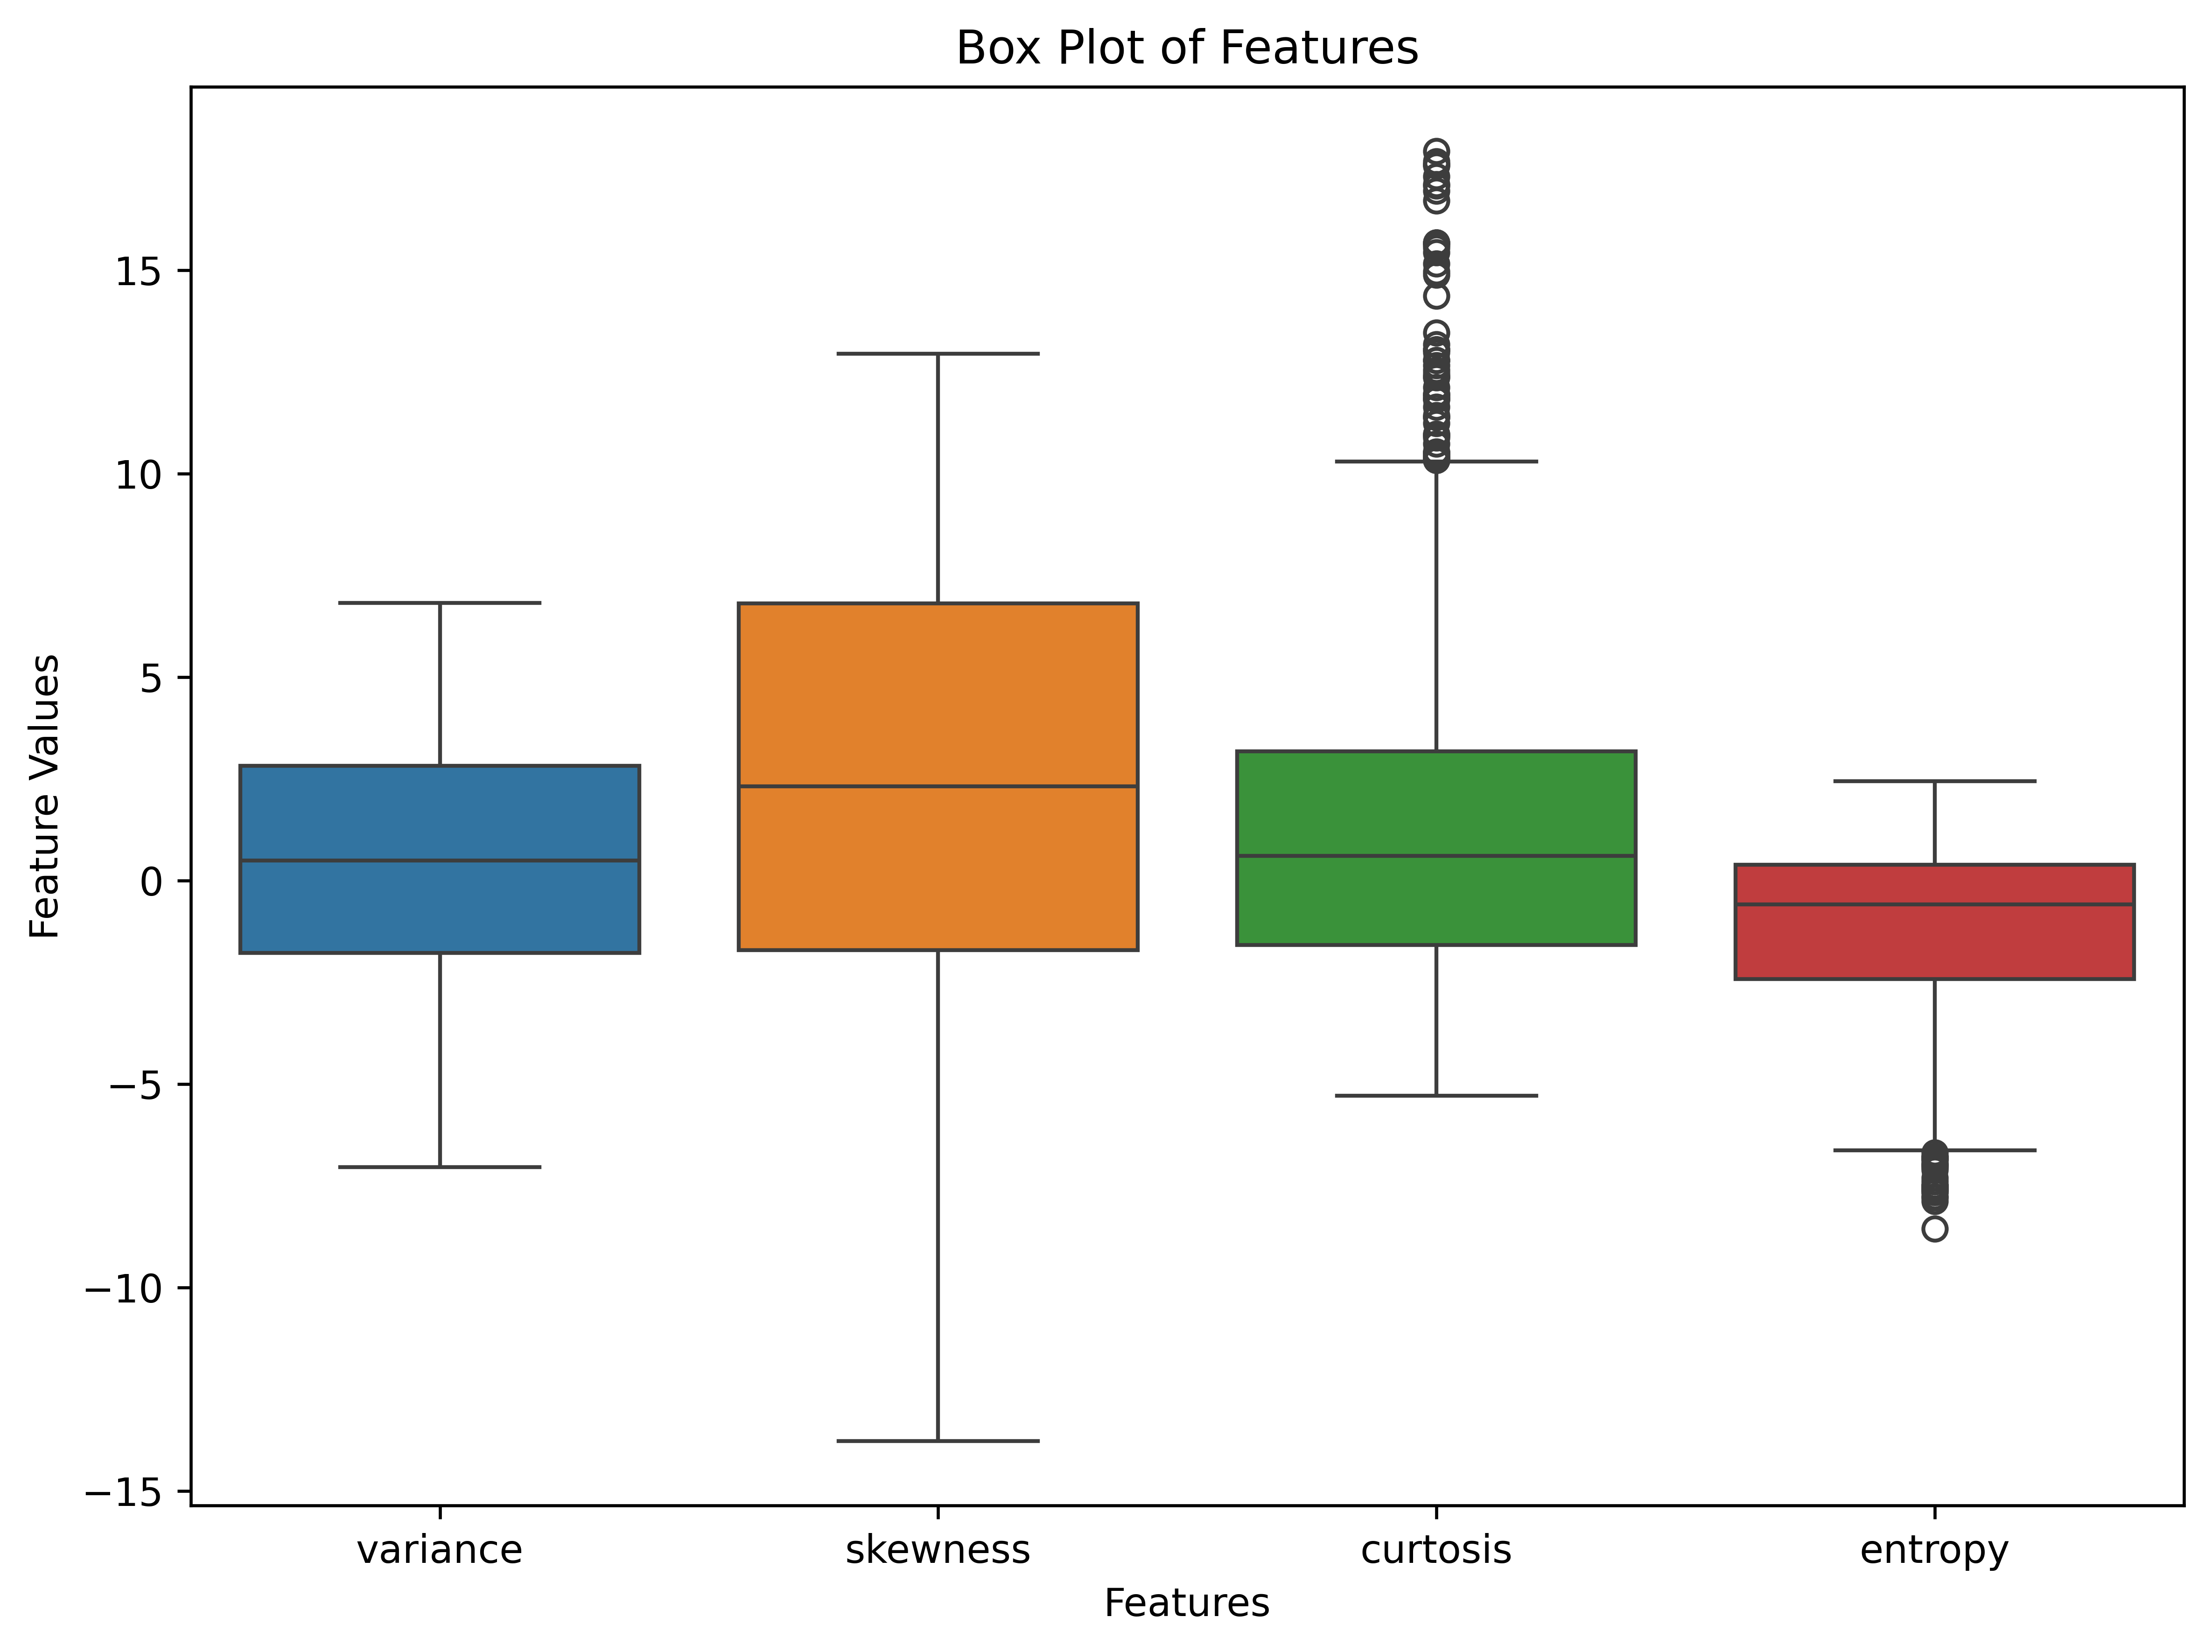

In [ ]:
plt.figure(figsize=(8,6), dpi=600)
sns.boxplot(data=bank_data.iloc[:, :-1])
plt.xlabel("Features")
plt.ylabel("Feature Values")
plt.title("Box Plot of Features")
plt.tight_layout()
plt.savefig("Box_Plot.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [ ]:
x = bank_data.iloc[:, :-1]
y = bank_data.iloc[:, -1]

normalize = MinMaxScaler()
x = normalize.fit_transform(x)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train = np.array(x_train)
X_test = np.array(x_test)

y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
class Perceptron:
    def __init__(self, learning_rate=0.01, epochs=20):
        self.lr = learning_rate
        self.epochs = epochs

    def step(self, x):
        if x >= 0:
            return 1
        else:
            return 0

    def fit(self, X, y):
        samples, features = X.shape
        self.weights = np.zeros(features)
        self.bias = 0
        self.errors = []
        self.weight_history = []
        self.bias_history = []
        for epoch in range(self.epochs):
            error = 0
            self.weight_history.append(self.weights.copy())
            self.bias_history.append(self.bias)
            for i in range(samples):
                z = np.dot(X[i], self.weights) + self.bias
                prediction = self.step(z)
                update = self.lr * (y[i] - prediction)
                self.weights = self.weights + update * X[i]
                self.bias = self.bias + update
                if update != 0:
                    error += 1
            self.errors.append(error)
            print("Epoch:", epoch+1)
            print("Misclassified:", error)
            print("Weights:", self.weights)
            print("Bias:", self.bias)
            print("-----------------------")

    def predict(self, X):
        predictions = []
        for x in X:
            z = np.dot(x, self.weights) + self.bias
            predictions.append(self.step(z))
        return np.array(predictions)

In [ ]:
model = Perceptron(learning_rate=0.01,epochs=20)
model.fit(X_train,y_train)

Epoch: 1
Misclassified: 166
Weights: [-0.06827408 -0.03866853 -0.05319097  0.01529354]
Bias: 0.08
-----------------------
Epoch: 2
Misclassified: 88
Weights: [-0.0831161  -0.06146315 -0.07687838  0.01162422]
Bias: 0.09999999999999999
-----------------------
Epoch: 3
Misclassified: 57
Weights: [-0.08731574 -0.0656554  -0.09593051  0.01506002]
Bias: 0.10999999999999999
-----------------------
Epoch: 4
Misclassified: 51
Weights: [-0.09538568 -0.07974311 -0.09285397  0.01017015]
Bias: 0.11999999999999998
-----------------------
Epoch: 5
Misclassified: 47
Weights: [-0.09778344 -0.0856403  -0.1002551   0.00578113]
Bias: 0.12999999999999998
-----------------------
Epoch: 6
Misclassified: 45
Weights: [-0.1058116  -0.08861835 -0.1014938   0.00433029]
Bias: 0.13999999999999999
-----------------------
Epoch: 7
Misclassified: 48
Weights: [-0.1116004  -0.09912635 -0.10830018  0.00909124]
Bias: 0.13999999999999999
-----------------------
Epoch: 8
Misclassified: 32
Weights: [-0.11796496 -0.1012441  -

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Accuracy:  0.9745454545454545
Precision:  0.9477611940298507
Recall:  1.0
F1 Score:  0.9731800766283525


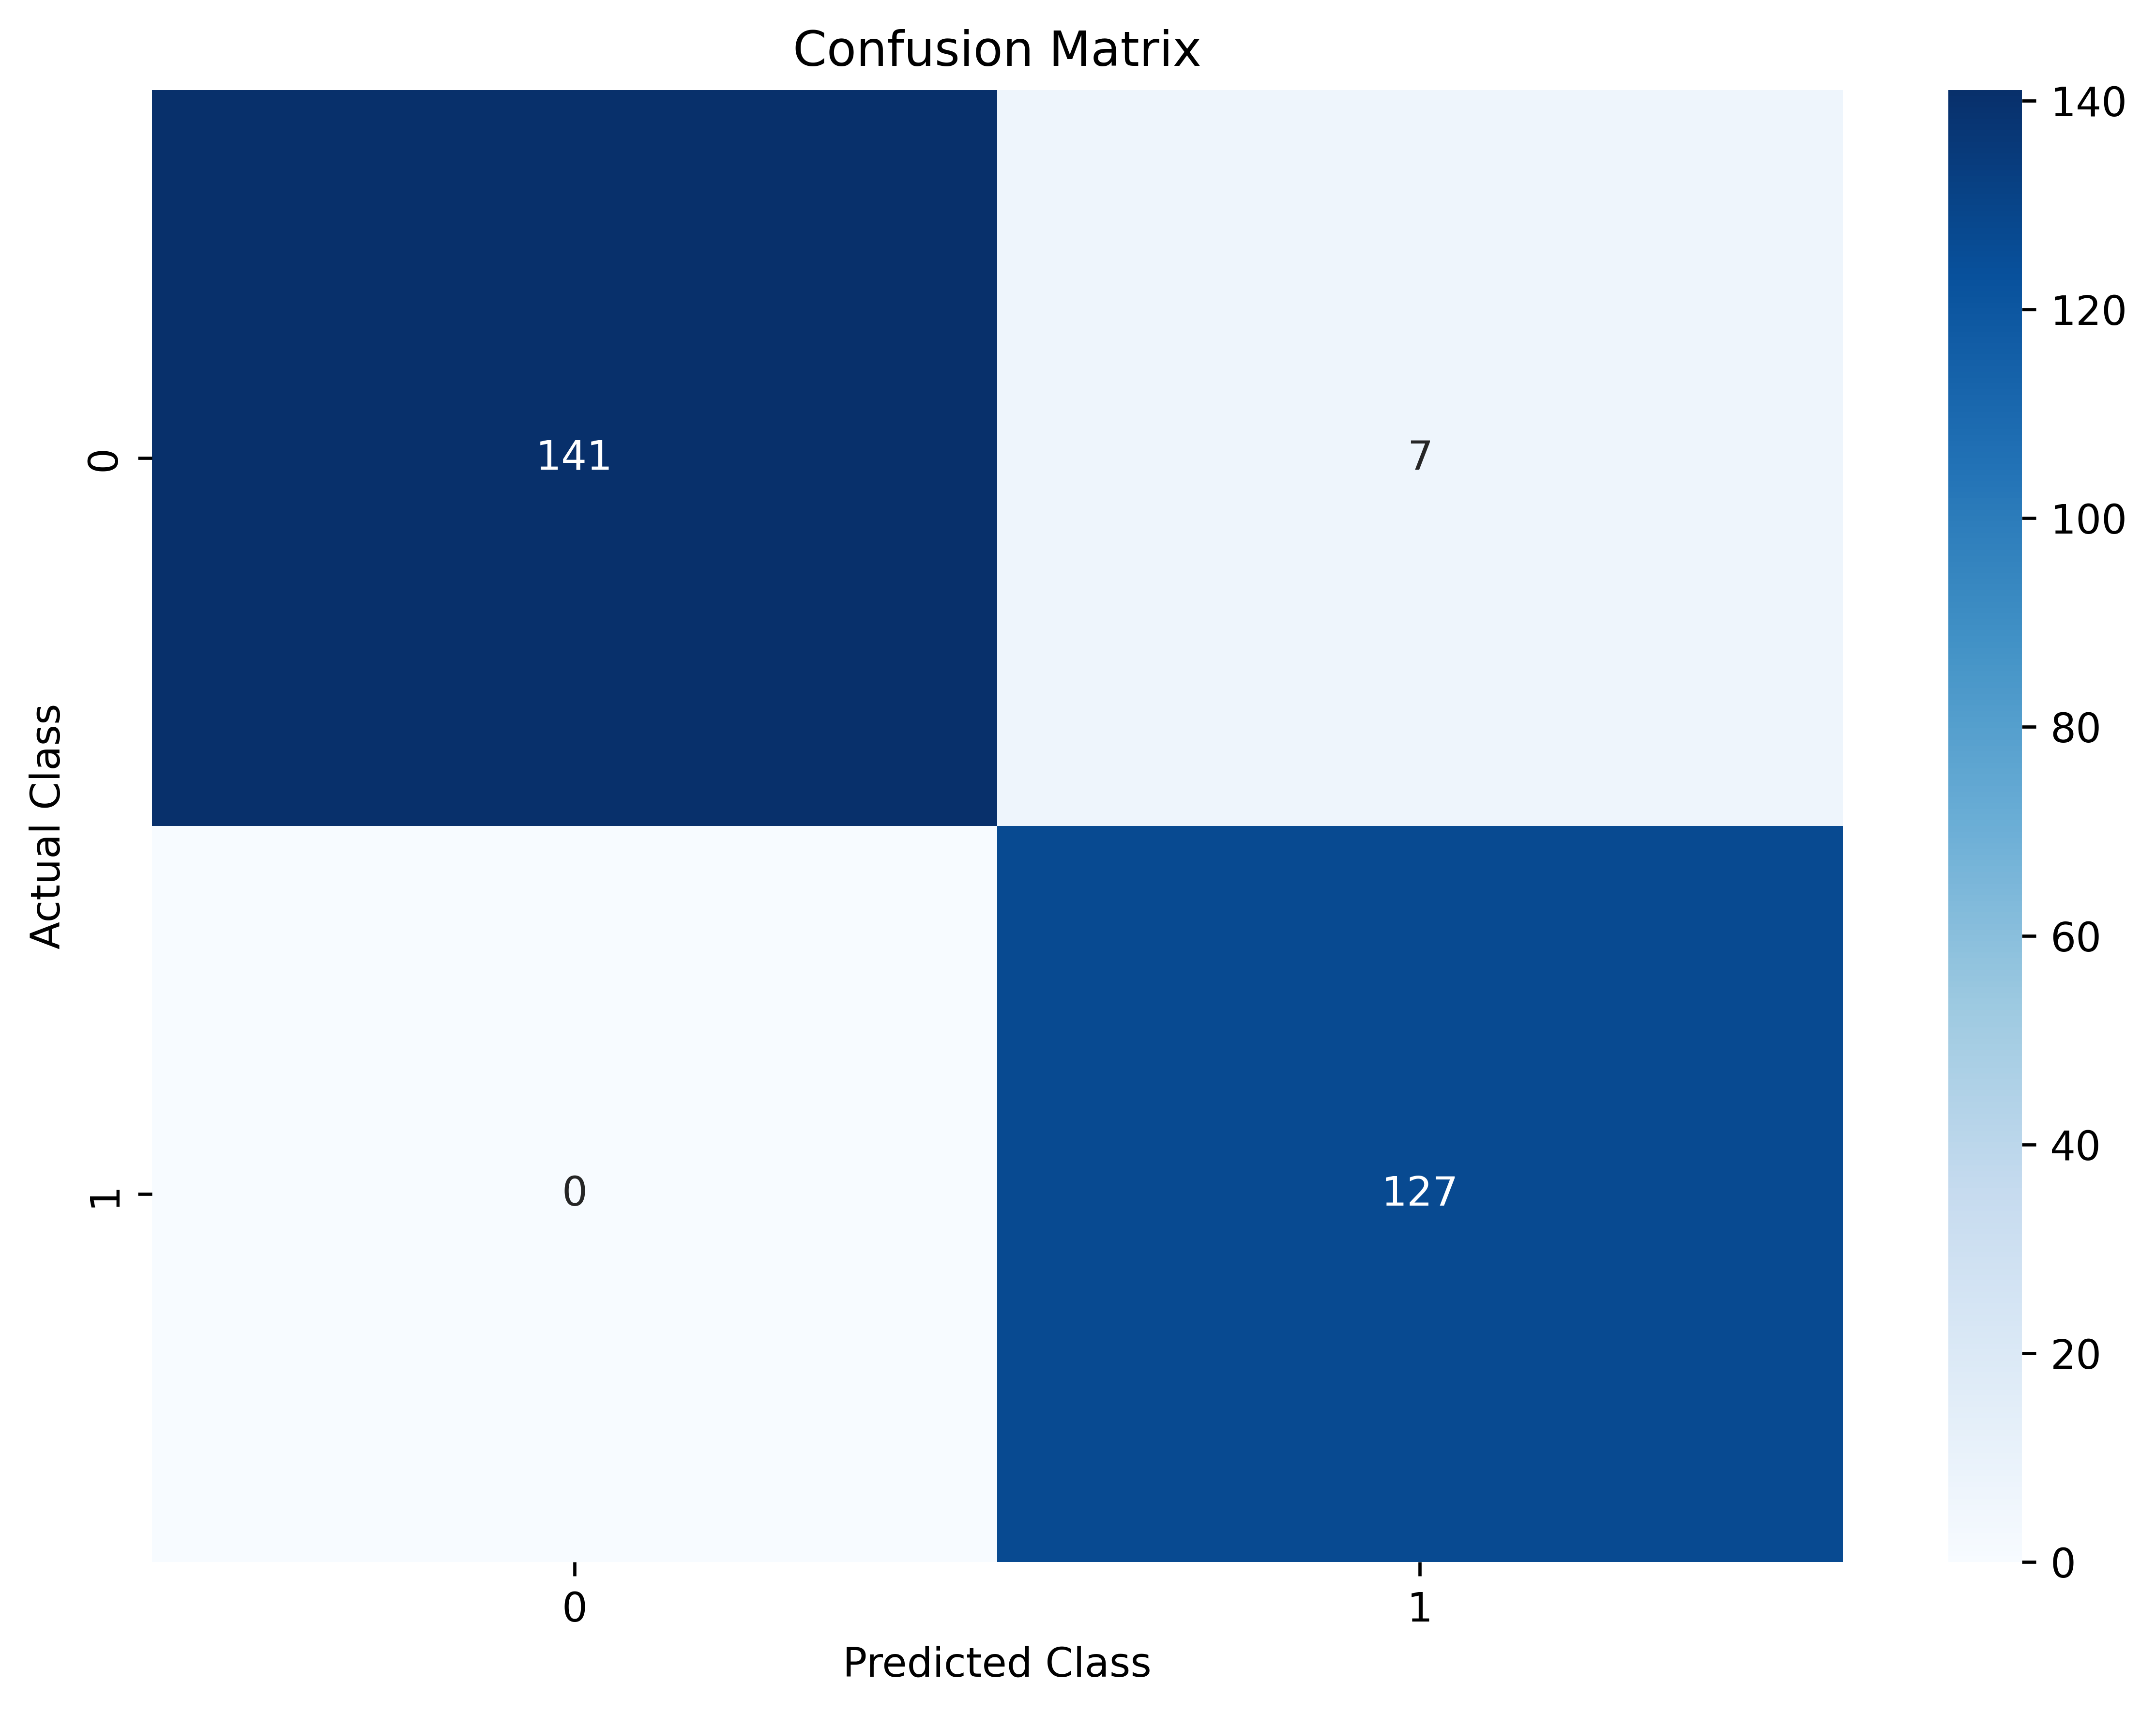

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6), dpi=600)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.savefig("Confusion_Matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

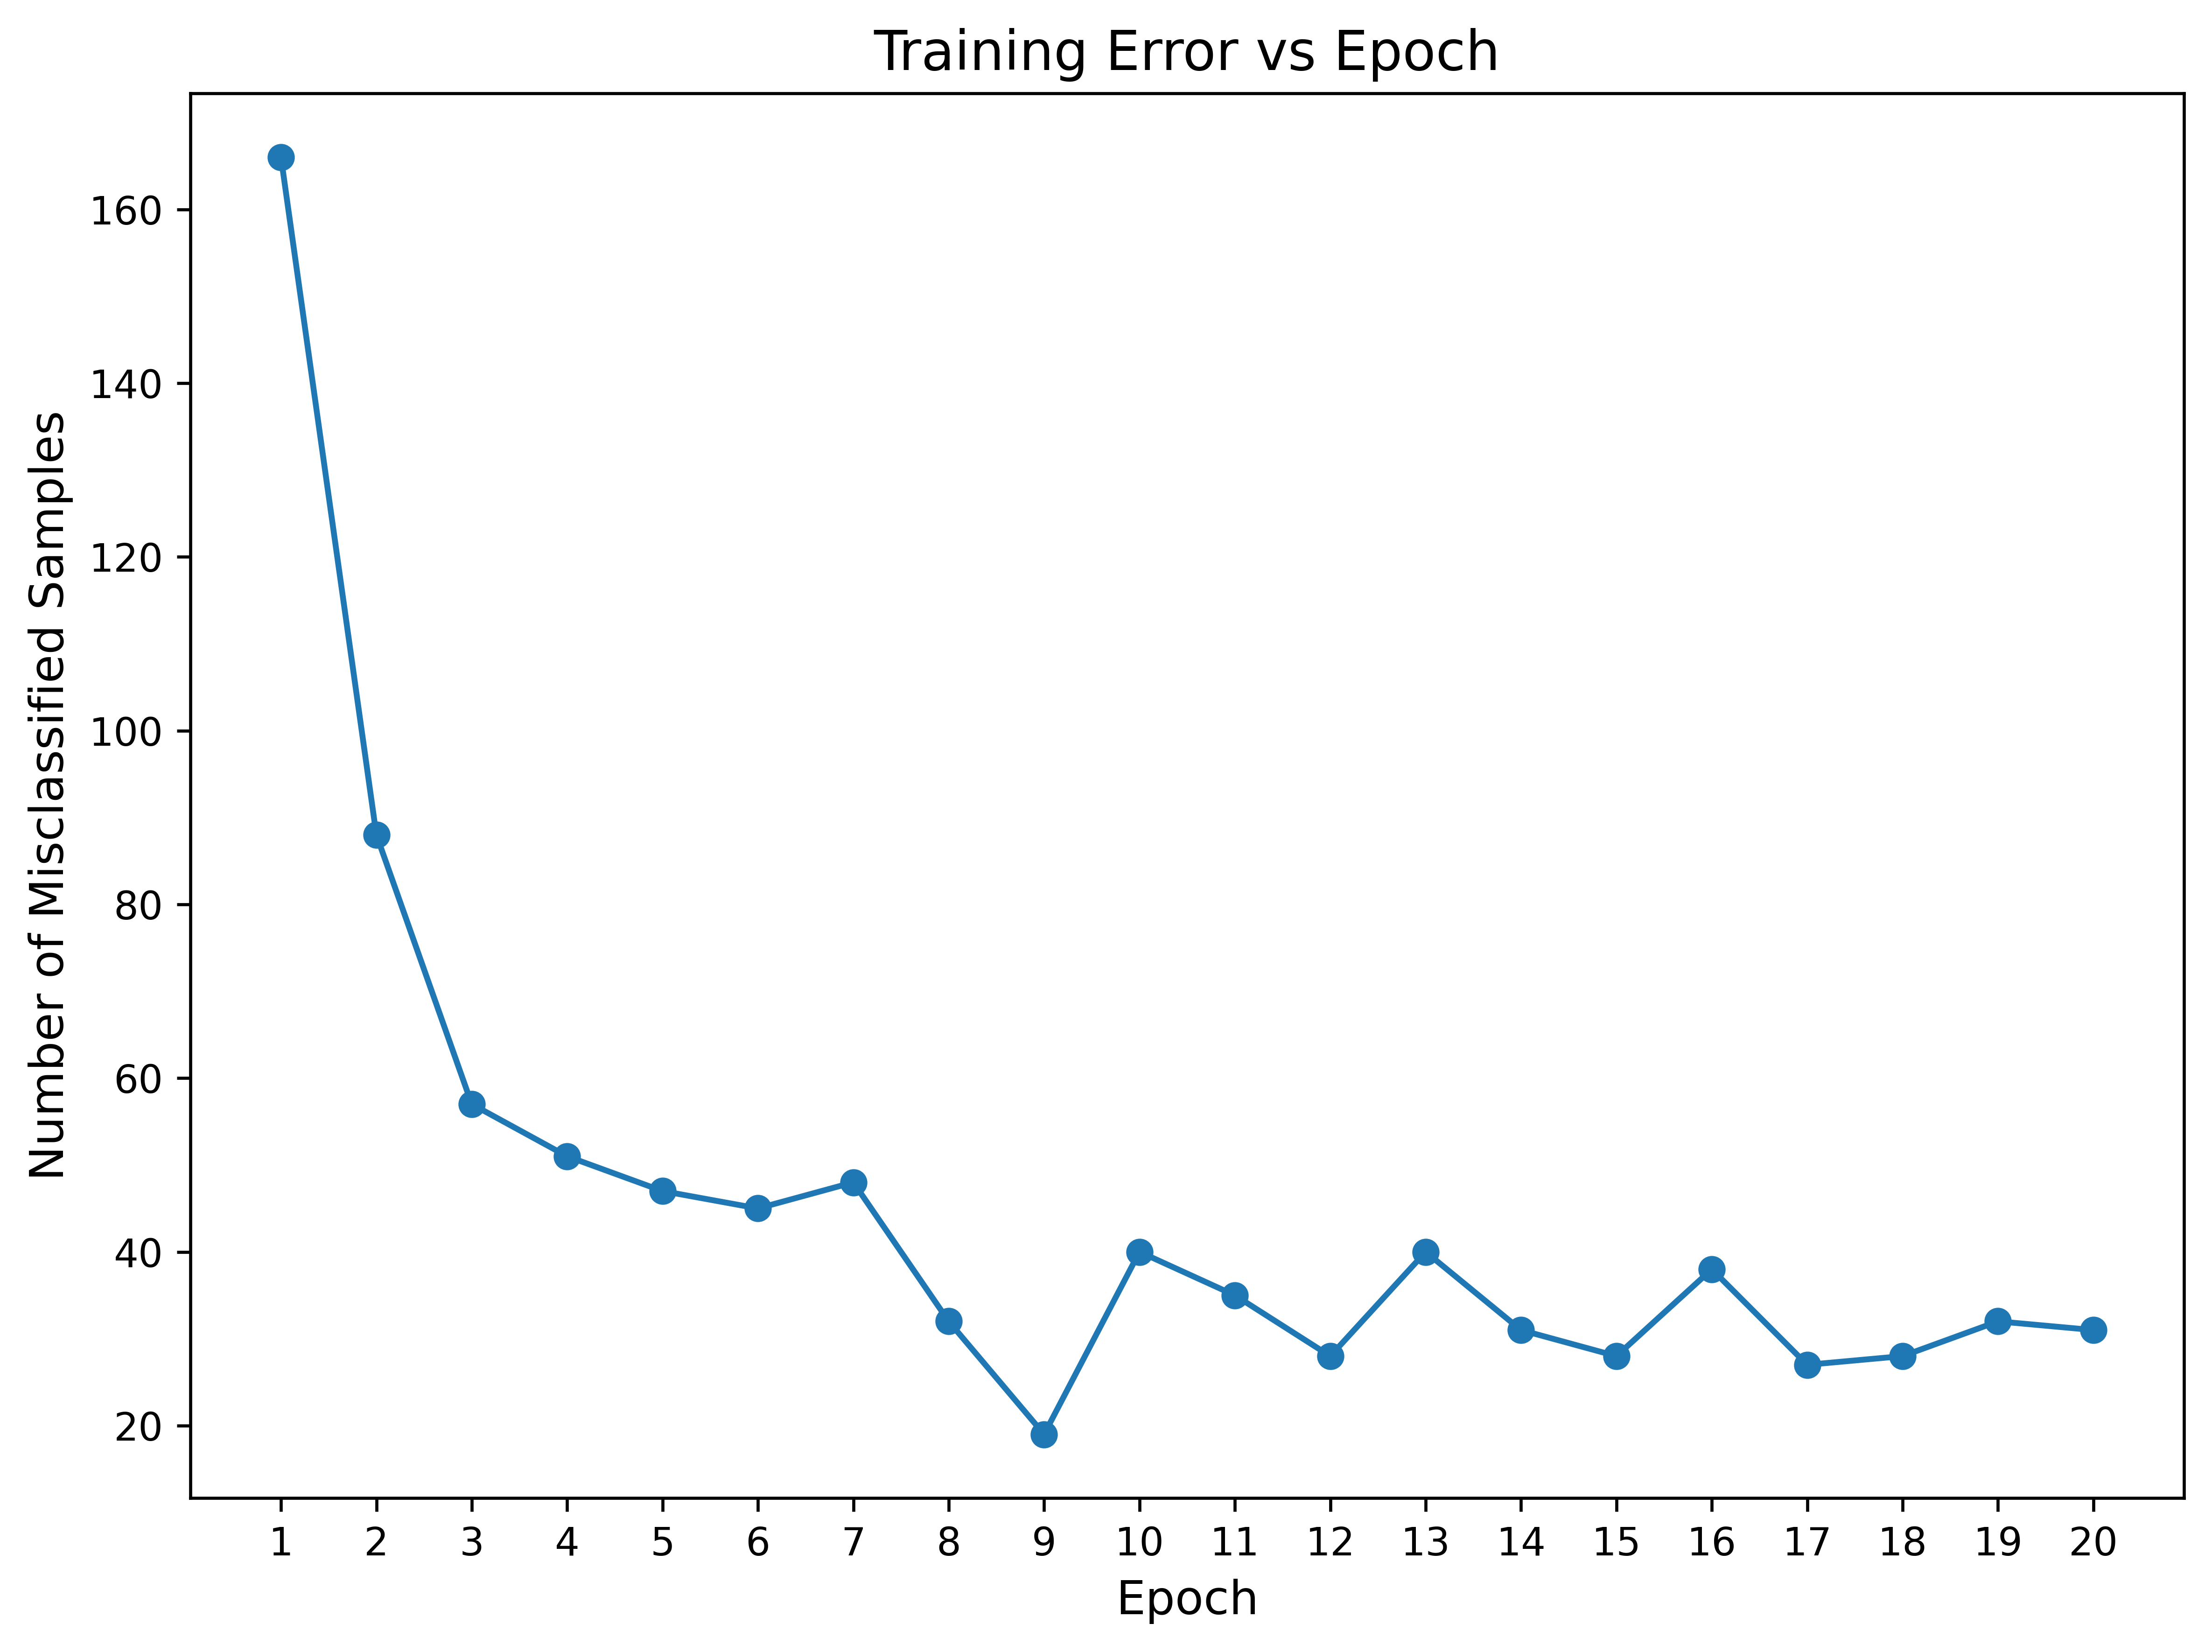

In [ ]:
plt.figure(figsize=(8,6), dpi=600)
plt.plot(range(1, len(model.errors)+1),model.errors,marker='o')
plt.title("Training Error vs Epoch", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Number of Misclassified Samples", fontsize=12)
plt.xticks(range(1, len(model.errors)+1))
plt.tight_layout()
plt.savefig("Training_Error_vs_Epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

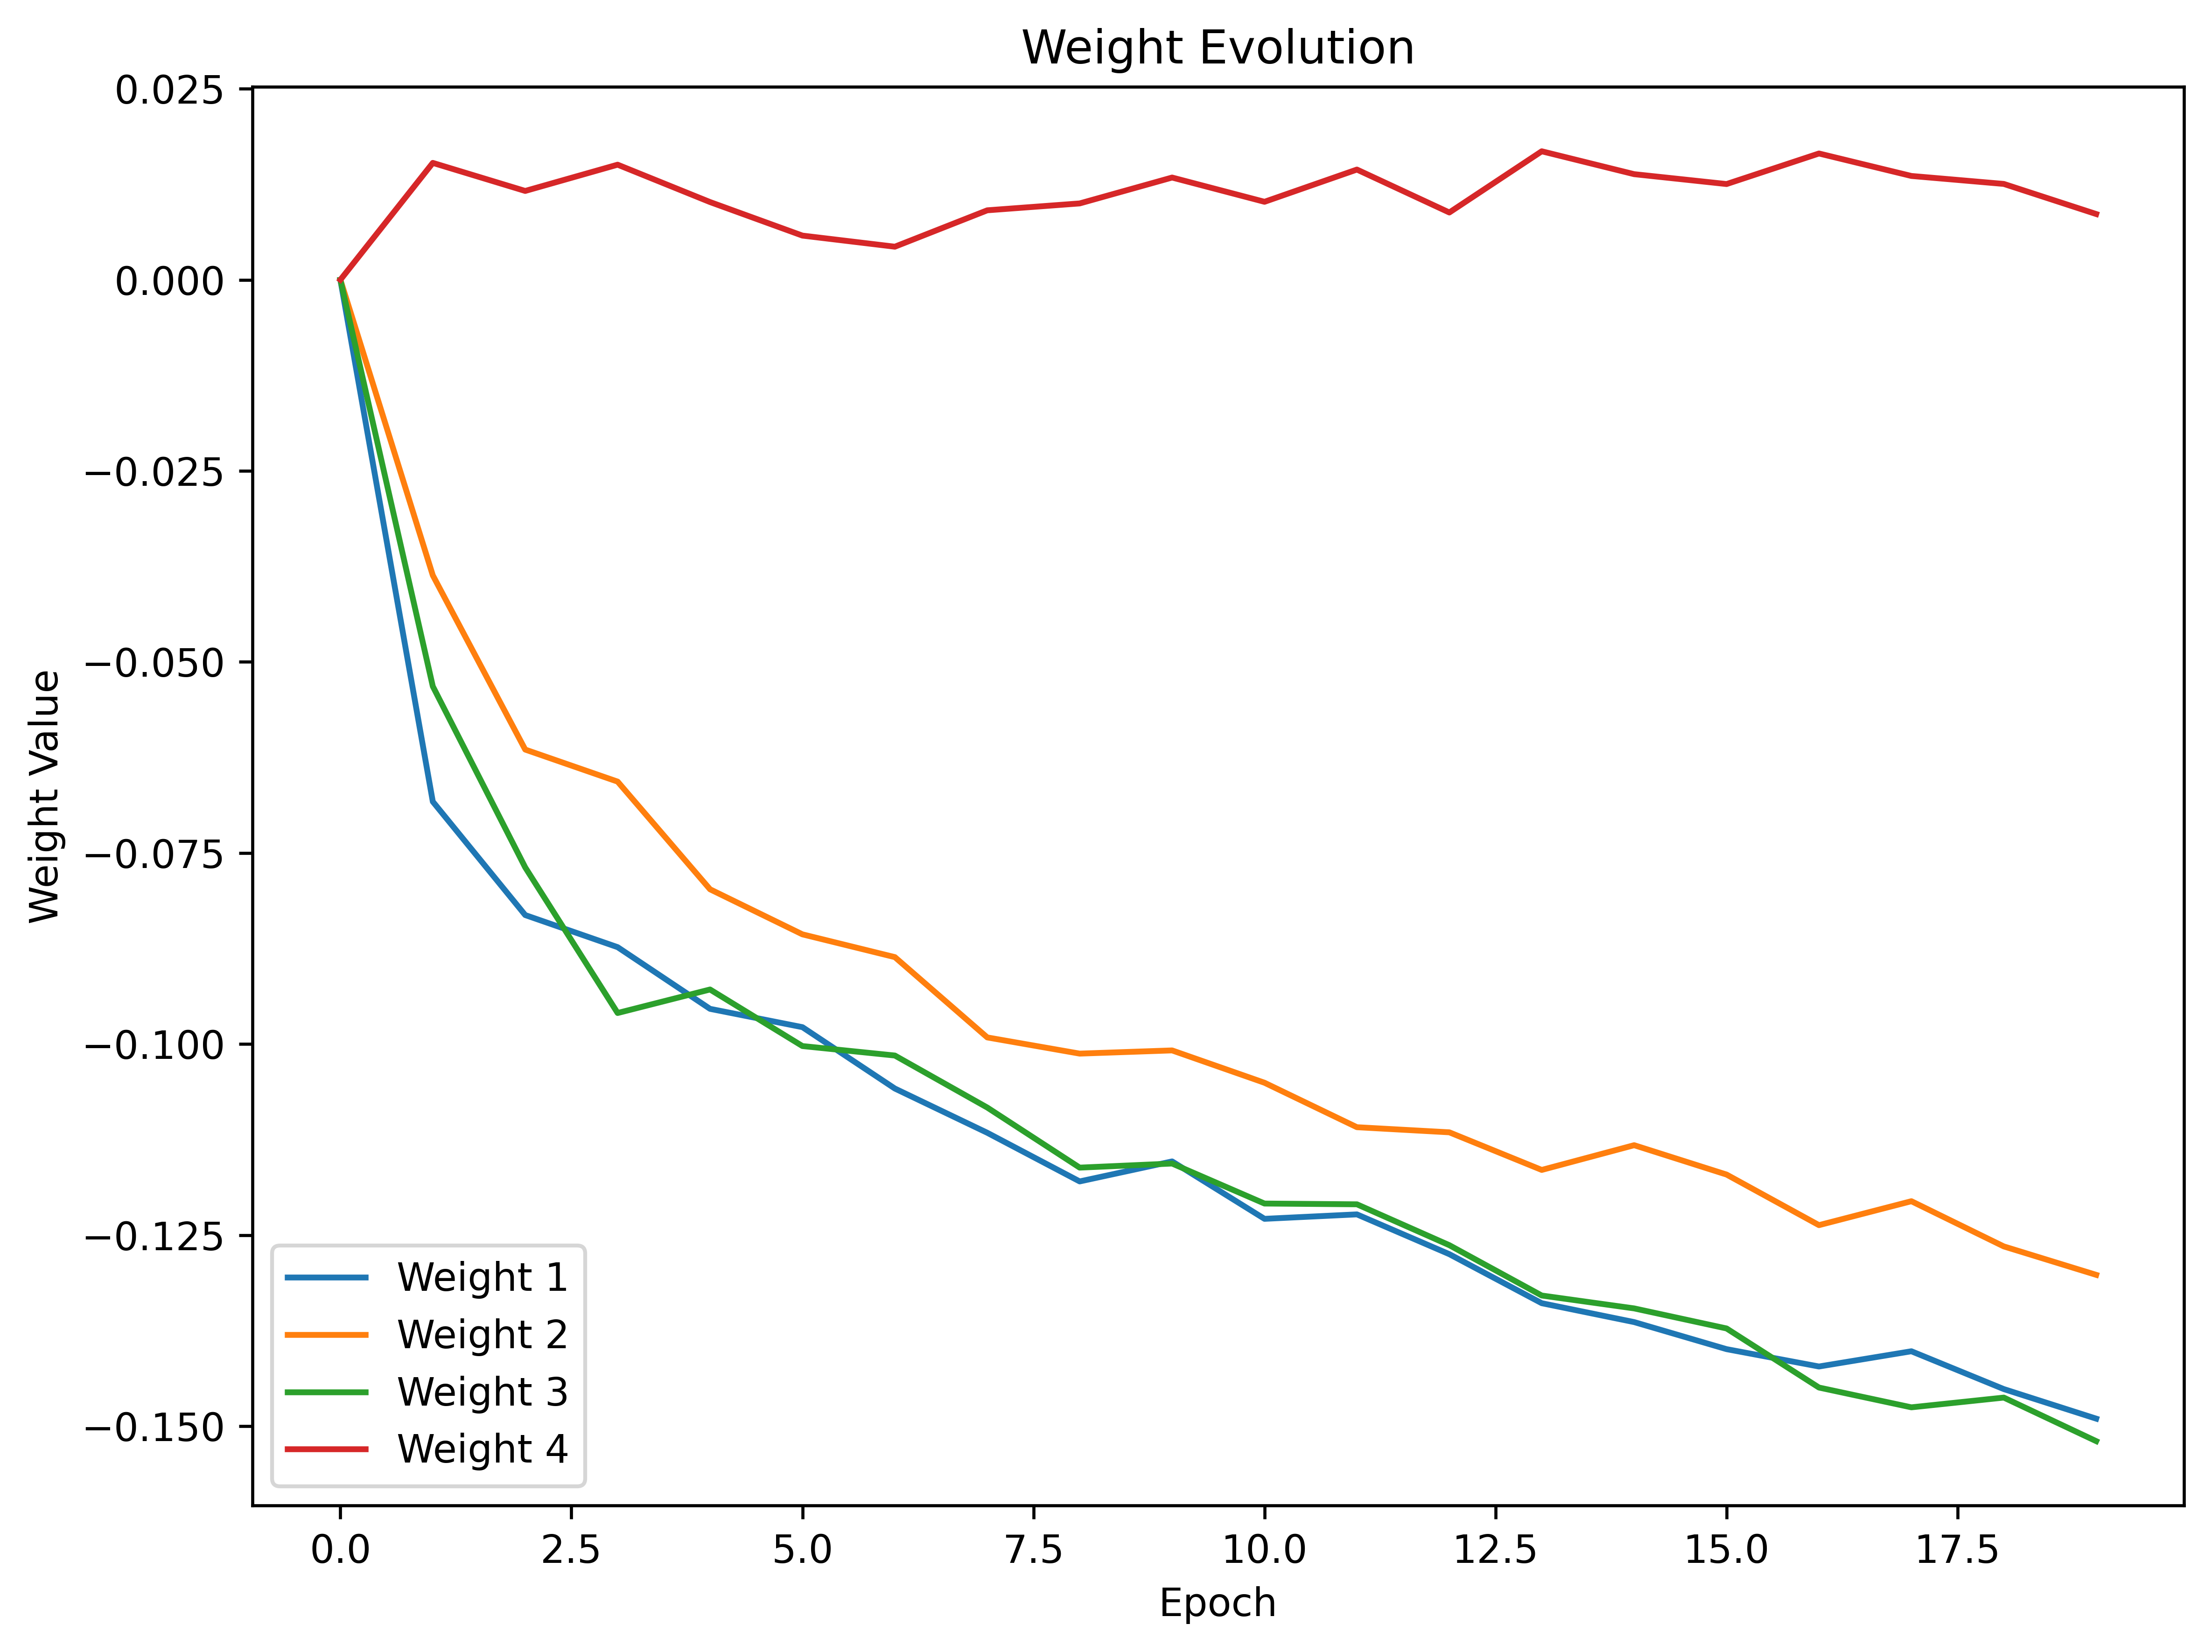

In [ ]:
plt.figure(figsize=(8,6),dpi=600)
weights = np.array(model.weight_history)
for i in range(weights.shape[1]):
    plt.plot(weights[:, i], label=f"Weight {i+1}")
plt.title("Weight Evolution")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend()
plt.tight_layout()
plt.savefig("Weight_Evolution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

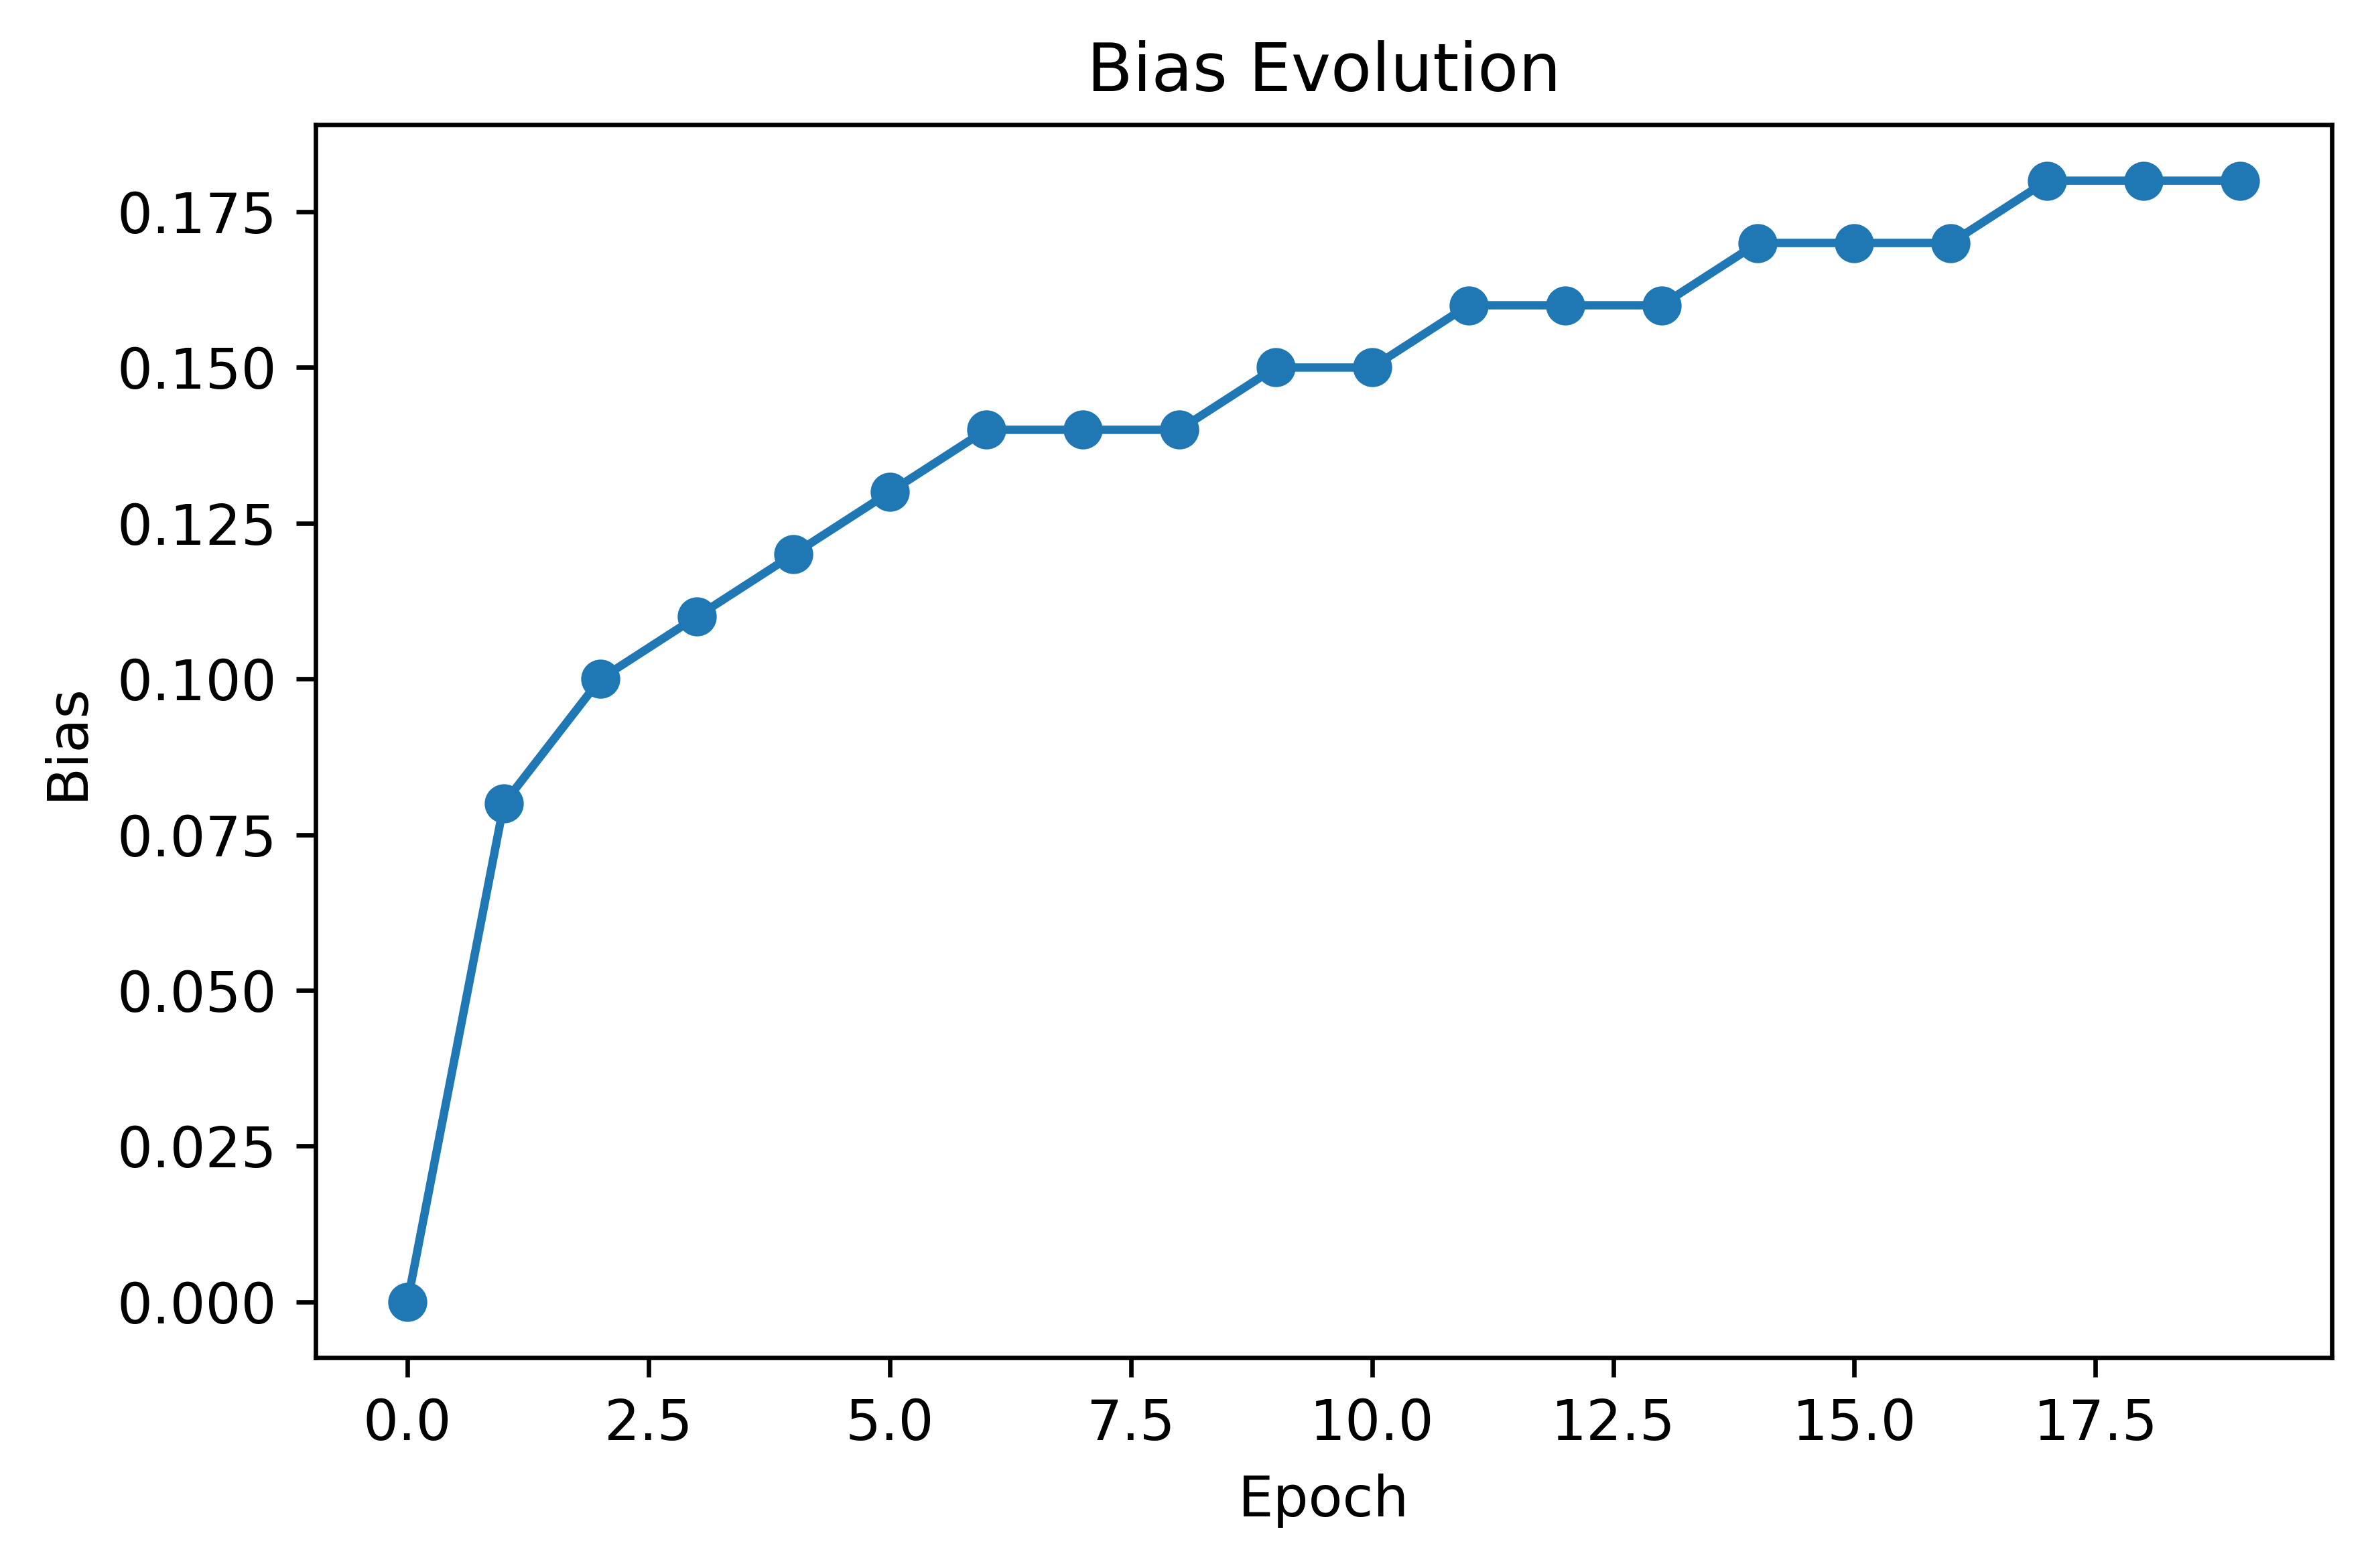

In [ ]:
plt.figure(figsize=(6,4), dpi=600)
plt.plot(model.bias_history,marker='o')
plt.title("Bias Evolution")
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.tight_layout()
plt.savefig("Bias_Evolution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

Epoch: 1
Misclassified: 166
Weights: [-0.00682741 -0.00386685 -0.0053191   0.00152935]
Bias: 0.008
-----------------------
Epoch: 2
Misclassified: 88
Weights: [-0.00831161 -0.00614632 -0.00768784  0.00116242]
Bias: 0.010000000000000002
-----------------------
Epoch: 3
Misclassified: 57
Weights: [-0.00873157 -0.00656554 -0.00959305  0.001506  ]
Bias: 0.011000000000000003
-----------------------
Epoch: 4
Misclassified: 51
Weights: [-0.00953857 -0.00797431 -0.0092854   0.00101702]
Bias: 0.012000000000000004
-----------------------
Epoch: 5
Misclassified: 47
Weights: [-0.00977834 -0.00856403 -0.01002551  0.00057811]
Bias: 0.013000000000000005
-----------------------
Epoch: 6
Misclassified: 45
Weights: [-0.01058116 -0.00886184 -0.01014938  0.00043303]
Bias: 0.014000000000000005
-----------------------
Epoch: 7
Misclassified: 48
Weights: [-0.01116004 -0.00991264 -0.01083002  0.00090912]
Bias: 0.014000000000000005
-----------------------
Epoch: 8
Misclassified: 32
Weights: [-0.0117965  -0.010

Epoch: 18
Misclassified: 28
Weights: [-1.45134053 -1.26469097 -1.46247348  0.1254181 ]
Bias: 1.8000000000000005
-----------------------
Epoch: 19
Misclassified: 32
Weights: [-1.4900295  -1.30189607 -1.51944219  0.086041  ]
Bias: 1.8000000000000005
-----------------------
Epoch: 20
Misclassified: 31
Weights: [-1.46411643 -1.32209723 -1.52145059  0.16122   ]
Bias: 1.9000000000000006
-----------------------


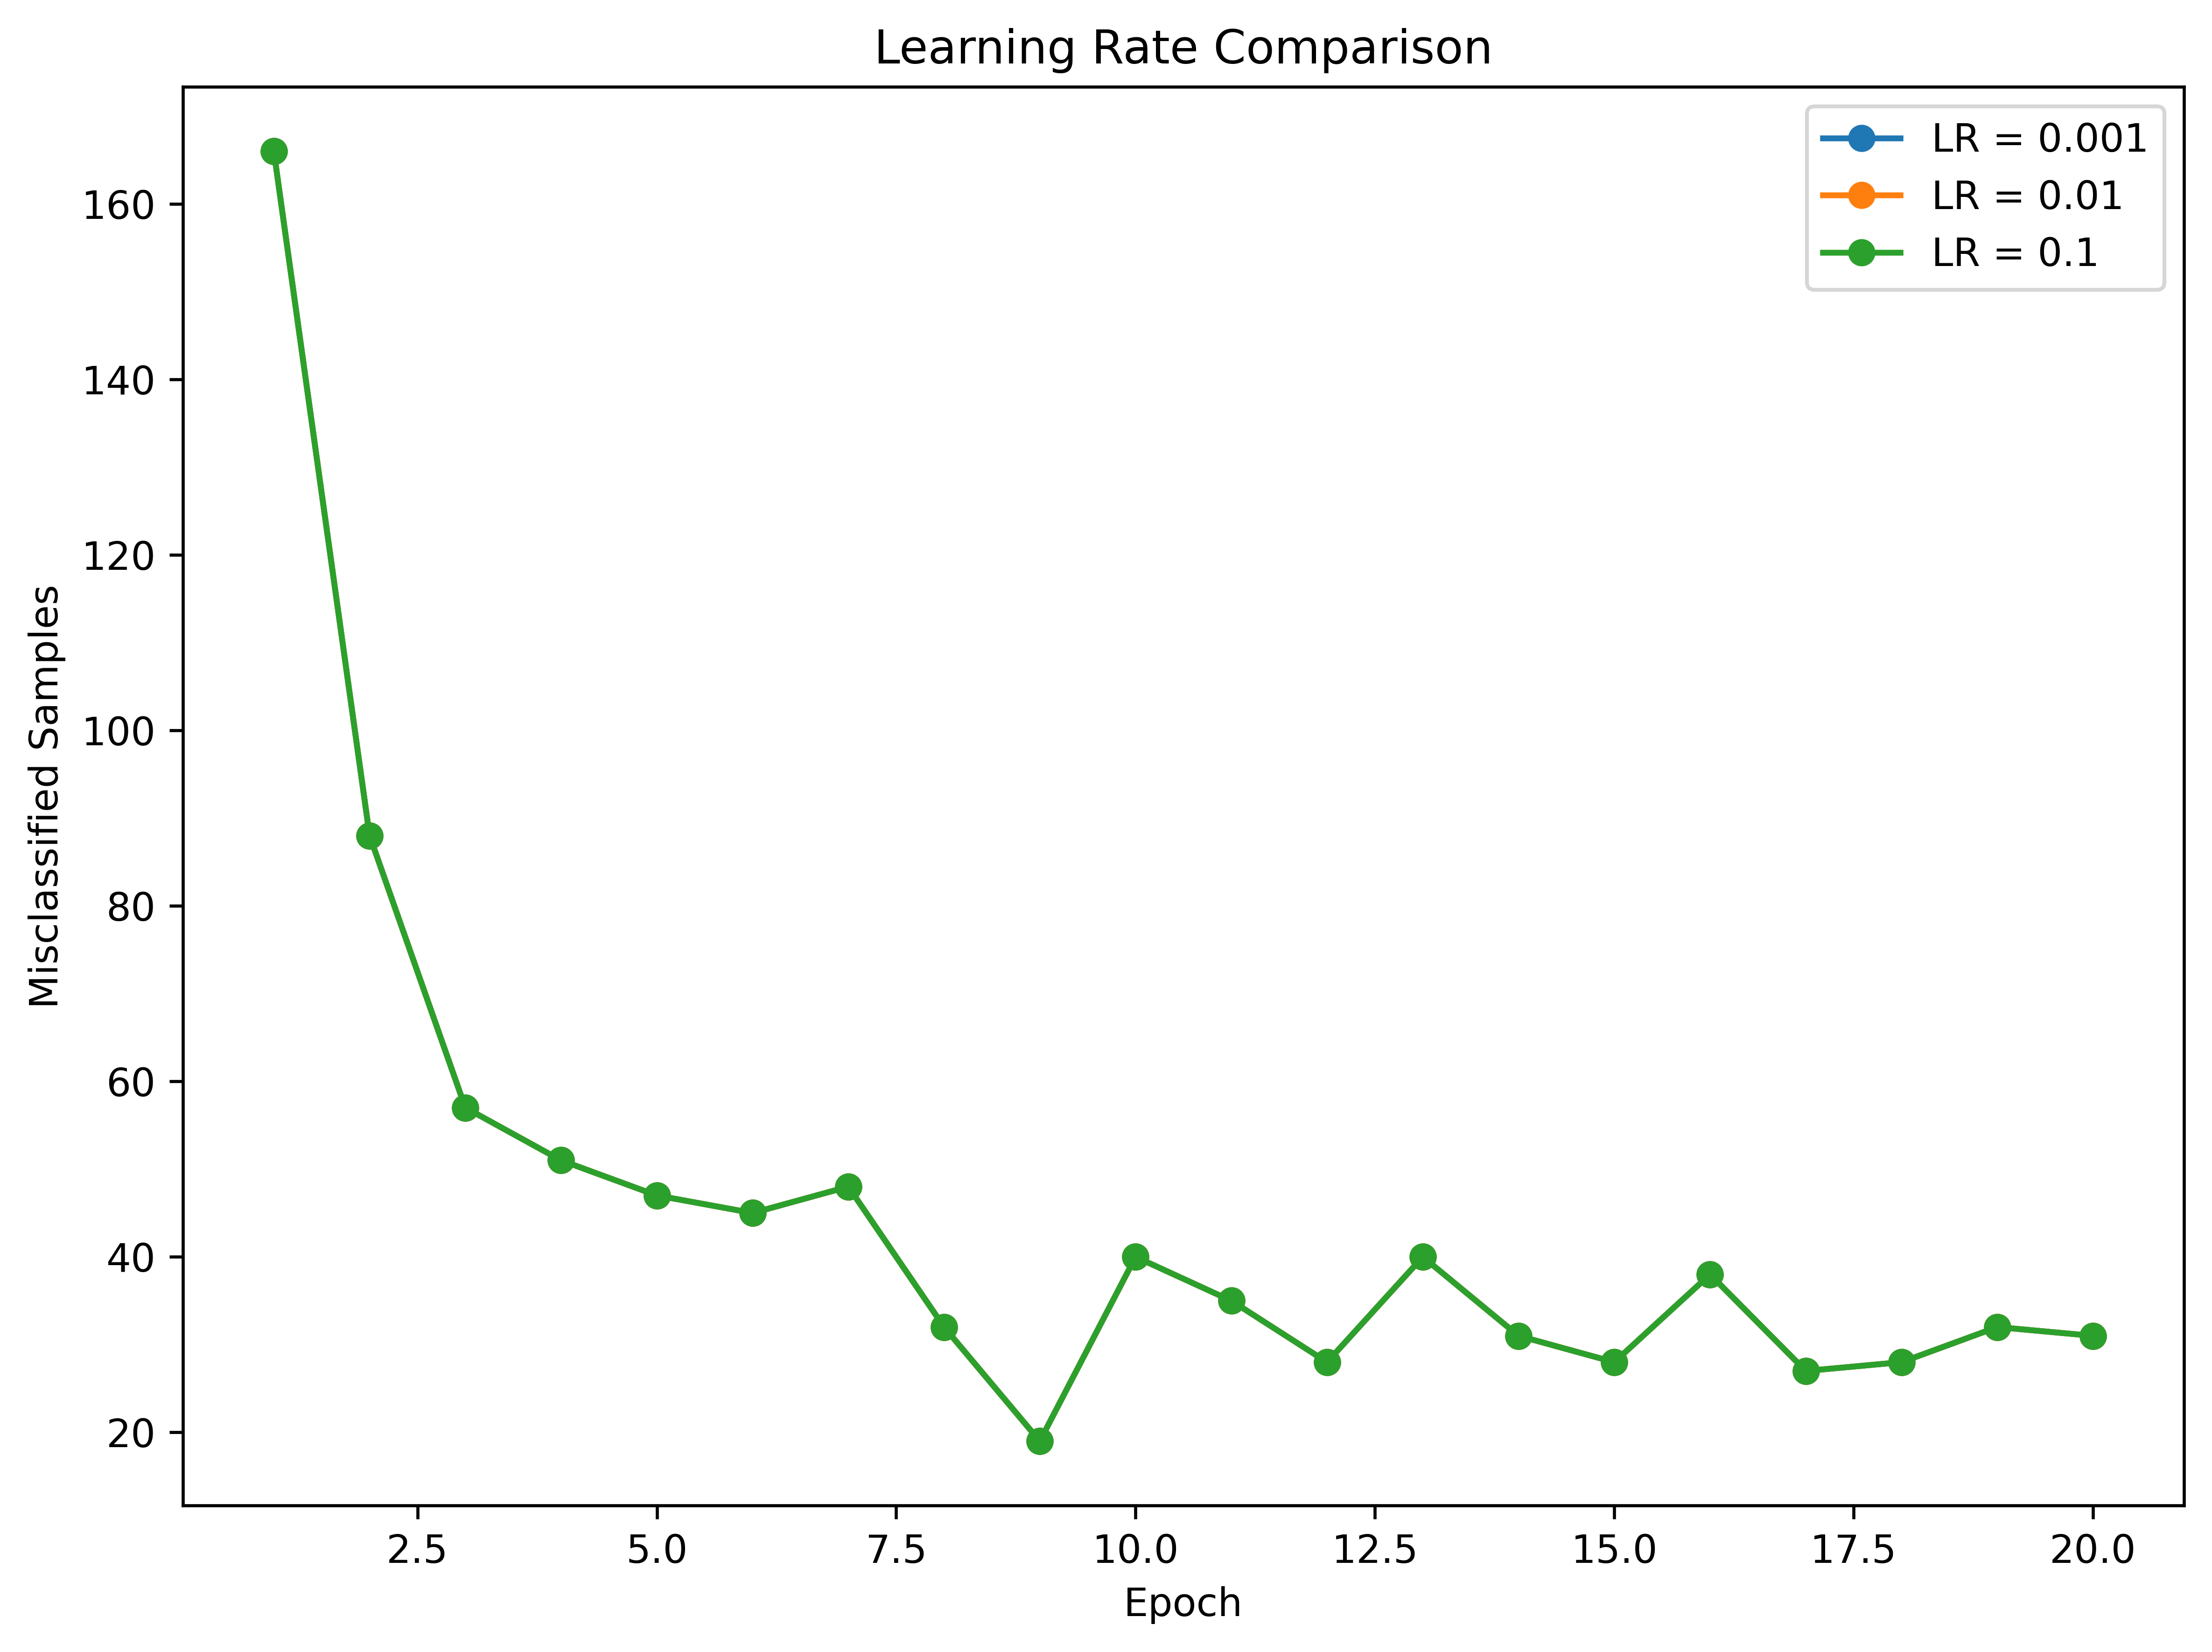

In [ ]:
plt.figure(figsize=(8,6), dpi=600)
rates = [0.001, 0.01, 0.1]
for lr in rates:
    model = Perceptron(learning_rate=lr, epochs=20)
    model.fit(X_train, y_train)
    plt.plot(range(1, len(model.errors)+1),model.errors,marker='o',label=f"LR = {lr}")
plt.title("Learning Rate Comparison")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.legend()
plt.tight_layout()
plt.savefig("Learning_Rate_Comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()